# Auto-validated binary pair specialist — seed42

## 가설
H0가 실제로 혼동한 암종쌍 중, inner OOF에서 binary specialist가 pair F1을 개선한 쌍만 보수적으로 적용하면 H0의 일부 경계 오류를 고칠 수 있습니다.

## 규칙 및 leakage 구조
- Outer: Stratified 5-fold seed42 / Inner: outer-train 내부 3-fold
- 암종쌍은 inner H0 OOF의 양방향 혼동에서 자동 탐지합니다. 고정 암종·유전자·mutation 목록은 없습니다.
- inner validation에서 pair F1 상승 및 `recovered > broken`인 쌍만, 서로 겹치지 않게 최대 2개 채택합니다.
- outer validation에는 선택·학습된 변환만 적용합니다. H0 Top-2가 선택 쌍과 정확히 일치할 때만 내부 확률 비율을 specialist로 바꾸며 pair 확률 질량은 보존합니다.
- test는 읽지 않고, train/test concat·test 통계·test encoding·threshold 탐색을 하지 않습니다. WT/blank/NaN은 event가 아닙니다.

전체 실행은 inner H0 OOF와 후보별 binary expert를 생성하므로 시간이 오래 걸릴 수 있습니다.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
RUNNER = ROOT / 'experiments/gs/notebooks/exp_model_006/common/run_auto_validated_pair_specialist.py'
RESULT = ROOT / 'experiments/gs/notebooks/exp_model_006/result'
RUN_ID = 'exp-auto-validated-pair-specialist-01'
RUN_EXPERIMENT = True
assert RUNNER.exists()
print({'runner': RUNNER, 'result_dir': RESULT, 'outer_seed': 42, 'inner_splits': 3, 'max_selected_pairs': 2, 'test_read': False})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/common/run_auto_validated_pair_specialist.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/result'), 'outer_seed': 42, 'inner_splits': 3, 'max_selected_pairs': 2, 'test_read': False}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='auto pair specialist', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('Auto-pair specialist runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 기존 result만 읽습니다.')

auto pair specialist: 1line [00:05,  5.60s/line]

[auto-pair] outer fold 1/5: inner OOF selection


auto pair specialist: 2line [06:59, 245.49s/line]

[auto-pair] outer fold 1/5: selected=[('KIPAN', 'KIRC')]


auto pair specialist: 3line [09:57, 215.05s/line]

...

auto pair specialist: 10line [47:31, 324.86s/line]

[auto-pair] outer fold 5/5: selected=[('GBMLGG', 'LGG'), ('KIPAN', 'KIRC')]


auto pair specialist: 11line [50:21, 277.26s/line]

{"seed": 42, "outer_splits": 5, "inner_splits": 3, "maximum_candidates": 8, "maximum_selected_pairs": 2, "test_read": false, "train_test_concat": false, "fixed_class_gene_mutation_rules": false, "pair_source": "outer_train_inner_oof_only", "leakage_check": true, "nan_as_mutation_count": 0, "convergence_warning_count": 0, "runtime_seconds": 3018.713932249986, "decision": "not_detected", "delta_vs_h0": 0.001640767408213395, "positive_fold_count": 2, "low_margin_delta": 0.005686040039670104, "h0_reference": 0.544744, "h0_reference_delta": -1.4001810832997563e-07}


auto pair specialist: 11line [50:21, 274.69s/line]


,variant,oof_macro_f1,oof_accuracy,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_h0
1,auto_validated_pair_specialist,0.546385,0.556362,8193.2,0,True,0,0.001641
0,H0,0.544744,0.555556,8193.2,0,True,0,0.000000


,outer_fold,selected,pair,inner_base_pair_f1,inner_specialist_pair_f1,pair_f1_delta,recovered,broken,inner_routed_rows
0,1,True,KIPAN|KIRC,0.572882,0.591096,0.018214,61,49,484
5,1,False,BRCA|SARC,0.471094,0.480290,0.009196,4,4,95
3,1,False,BRCA|PRAD,0.532161,0.537904,0.005743,6,6,103
2,1,False,BRCA|OV,0.593095,0.593677,0.000582,13,17,172
4,1,False,BRCA|KIPAN,0.662645,0.662645,0.000000,7,7,63
6,1,False,PRAD|THCA,0.572207,0.565388,-0.006820,1,3,69
7,1,False,BRCA|PCPG,0.566298,0.558117,-0.008181,4,7,101
1,1,False,GBMLGG|LGG,0.570264,0.556241,-0.014022,41,44,372
12,2,False,BRCA|SARC,0.456798,0.462277,0.005479,6,7,101
11,2,False,BRCA|PRAD,0.575553,0.580499,0.004946,7,8,73


,outer_fold,pair,routed_rows,fit_support
0,1,KIPAN|KIRC,125,679
1,3,GBMLGG|LGG,92,552
2,3,LUAD|LUSC,29,290
3,4,LUAD|LUSC,24,289
4,4,KIPAN|KIRC,122,680
5,5,GBMLGG|LGG,90,552
6,5,KIPAN|KIRC,132,679


,group,support,H0_macro_f1,specialist_macro_f1,delta
0,H0_margin_<0.05,1120,0.237845,0.243531,0.005686


자동 판정: not_detected
{'delta_vs_h0': 0.001640767408213395, 'positive_fold_count': 2, 'low_margin_delta': 0.005686040039670104, 'runtime_seconds': 3018.713932249986}


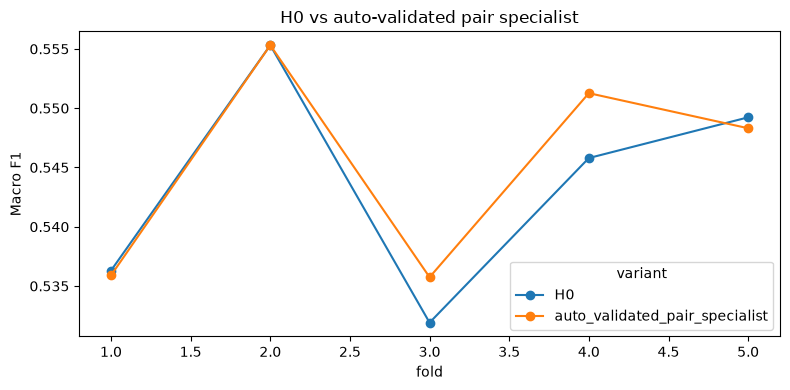

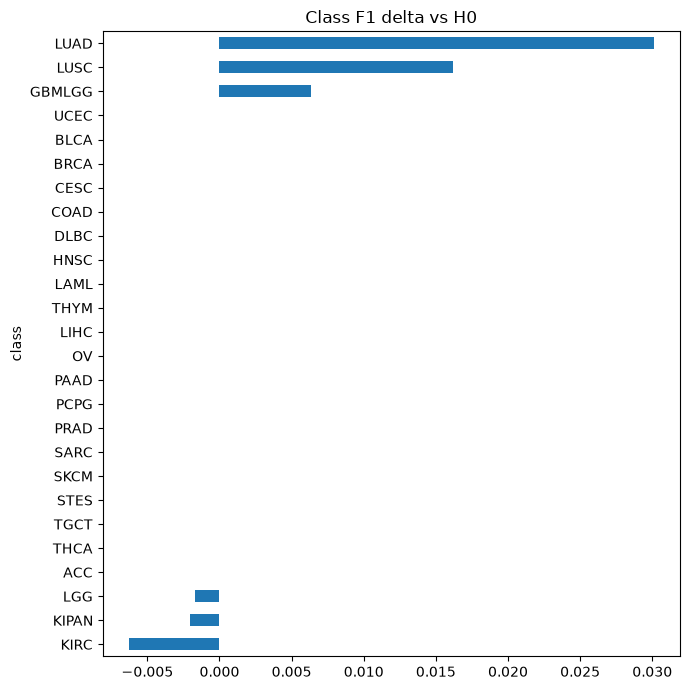

In [3]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed42_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
candidates = pd.read_csv(RESULT / f'{RUN_ID}_seed42_inner_candidate_audit.csv')
applied = pd.read_csv(RESULT / f'{RUN_ID}_seed42_applied_pairs.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed42_class_metrics.csv')
low_margin = pd.read_csv(RESULT / f'{RUN_ID}_seed42_low_margin.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed42_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values('oof_macro_f1', ascending=False))
display(candidates.sort_values(['outer_fold', 'selected', 'pair_f1_delta'], ascending=[True, False, False]).head(30))
display(applied)
display(low_margin)
print('자동 판정:', audit['decision'])
print({key: audit[key] for key in ('delta_vs_h0', 'positive_fold_count', 'low_margin_delta', 'runtime_seconds')})

folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', figsize=(8, 4), title='H0 vs auto-validated pair specialist')
plt.ylabel('Macro F1'); plt.tight_layout(); plt.show()
classes.set_index('class').delta.sort_values().plot.barh(figsize=(7, 7), title='Class F1 delta vs H0')
plt.tight_layout(); plt.show()